In [ ]:
!git clone https://github.com/jeminanda/hometrainer.git

In [ ]:
!pip install kagglehub

In [4]:
import sys
from pathlib import Path
import numpy as np

# 1. 프로젝트 루트 경로 설정 (노트북 위치에 맞게 필요시 Path("..") 조절)
project_root = Path(".").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 2. 추출기 모듈 불러오기
from src.pose_extraction.pose_extractor import(
    BlazePoseExtractor,
    ExtractionConfig,
    PoseNotDetectedError
)

print("✅ BlazePoseExtractor 로드 완료!")

✅ BlazePoseExtractor 로드 완료!


In [ ]:
# -------------------------------------------------------------
# 설정 (ExtractionConfig)
# -------------------------------------------------------------
config = ExtractionConfig(
    model_path="models/pose_landmarker_full.task", # .task 모델 경로
    include_z=True,            # Z 좌표 포함 여부 (x, y, z, visibility = 4채널)
    target_fps=None,           # None인 경우 원본 영상 FPS 사용
    min_detected_ratio=0.1     # 최소 포즈 검출 비율 (10%)
)

# 입력 영상 및 저장할 .npy 파일 경로 설정
video_path = "data/raw/squat_001.mp4"
output_npy_path = "data/raw/squat_001_keypoints.npy"

# -------------------------------------------------------------
# 키포인트 추출 실행
# -------------------------------------------------------------
try:
    with BlazePoseExtractor(config) as extractor:
        print(f"🎥 [{video_path}] 키포인트 추출 시작...")
        keypoints, meta = extractor.extract_from_video(video_path)

    print("\n✅ 추출 성공!")
    print(f"• Keypoints Shape (T, J, C): {keypoints.shape}")
    print(f"• Metadata: {meta}")

    # .npy 파일 저장
    save_path = Path(output_npy_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(save_path, keypoints)
    print(f"💾 저장 완료: {save_path.resolve()}")

except PoseNotDetectedError as e:
    print(f"❌ 포즈 검출 실패: {e}")
except FileNotFoundError as e:
    print(f"❌ 파일을 찾을 수 없습니다: {e}")
except Exception as e:
    print(f"❌ 에러 발생: {e}")

In [5]:
# -------------------------------------------------------------
# 키워드 기반 배치 추출: EXERCISE_KEYWORD만 바꾸면 다른 운동으로 전환됩니다.
# 예) "pushup" -> "squat"
# -------------------------------------------------------------
EXERCISE_KEYWORD = "squat"

config = ExtractionConfig(
    model_path="models/pose_landmarker_full.task", # .task 모델 경로
    include_z=True,            # Z 좌표 포함 여부 (x, y, z, visibility = 4채널)
    target_fps=None,           # None인 경우 원본 영상 FPS 사용
    min_detected_ratio=0.1,    # 최소 포즈 검출 비율 (10%)
    use_gpu=True,              # GPU delegate 사용 (지원 안 되는 환경/영상에서는 자동으로 CPU로 대체됨)
)

raw_dir = Path("data/raw")
# 파일명에 EXERCISE_KEYWORD가 포함된 영상만 순회 (대소문자 무관, OS와 무관하게 항상 동일하게 동작)
video_files = sorted(
    p for p in raw_dir.glob("*.mp4")
    if EXERCISE_KEYWORD.lower() in p.stem.lower()
)
print(f"🔍 '{EXERCISE_KEYWORD}' 키워드 포함 비디오 {len(video_files)}개 발견 (GPU 사용: {config.use_gpu})\n")

for vid_path in video_files:
    # 원본 영상 파일명을 그대로 쓰지 않고, EXERCISE_KEYWORD를 접두사로 강제로 붙여
    # build_dataset.py가 기대하는 {exercise}_{video_id}_keypoints.npy 규칙을 항상 만족시킨다.
    # 원본 파일명이 "my_pushup_03.mp4"처럼 규칙과 안 맞아도(대소문자/하이픈/중복 키워드 등)
    # 영상 파일을 직접 리네이밍할 필요 없이 exercise가 항상 EXERCISE_KEYWORD로 정확히 잡힌다.
    output_file = vid_path.parent / f"{EXERCISE_KEYWORD}_{vid_path.stem}_keypoints.npy"

    try:
        # 영상마다 새 BlazePoseExtractor를 생성합니다 — PoseLandmarker(VIDEO 모드)는
        # 프레임 타임스탬프가 반드시 단조 증가해야 하는데, 같은 extractor를 여러 영상에
        # 재사용하면 다음 영상의 타임스탬프가 0부터 다시 시작되어 이 제약을 어기게 됩니다.
        # (GPU delegate를 쓰더라도 이 제약은 동일하게 적용되므로 구조는 그대로 유지합니다.)
        with BlazePoseExtractor(config) as extractor:
            print(f"🔄 처리 중: {vid_path.name} -> {output_file.name}")
            keypoints, meta = extractor.extract_from_video(vid_path)

        np.save(output_file, keypoints)
        print(f"   ↳ 완료! Shape: {keypoints.shape}, 검출률: {meta['detected_ratio']:.1%}")

    except PoseNotDetectedError as e:
        print(f"   ↳ ⚠️ 스킵 (포즈 미검출): {e}")
    except Exception as e:
        print(f"   ↳ ❌ 실패: {e}")

print("\n🎉 모든 영상 처리 완료!")


🔍 'squat' 키워드 포함 비디오 12개 발견 (GPU 사용: True)

🔄 처리 중: squat (1).mp4 -> squat_squat (1)_keypoints.npy
[경고] GPU delegate 초기화 실패(ValidatedGraphConfig Initialization failed.
ImageCloneCalculator: GPU processing is disabled in build flags
ImageCloneCalculator: GPU processing is disabled in build flags) -> CPU로 대체합니다.
   ↳ 완료! Shape: (867, 33, 4), 검출률: 100.0%
🔄 처리 중: squat (10).mp4 -> squat_squat (10)_keypoints.npy
[경고] GPU delegate 초기화 실패(ValidatedGraphConfig Initialization failed.
ImageCloneCalculator: GPU processing is disabled in build flags
ImageCloneCalculator: GPU processing is disabled in build flags) -> CPU로 대체합니다.
   ↳ 완료! Shape: (2635, 33, 4), 검출률: 100.0%
🔄 처리 중: squat (11).mp4 -> squat_squat (11)_keypoints.npy
[경고] GPU delegate 초기화 실패(ValidatedGraphConfig Initialization failed.
ImageCloneCalculator: GPU processing is disabled in build flags
ImageCloneCalculator: GPU processing is disabled in build flags) -> CPU로 대체합니다.
   ↳ 완료! Shape: (286, 33, 4), 검출률: 100.0%
🔄 처리 중: squat (12).mp

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# hometrainer/src/preprocessing 경로에서 모듈 불러오기
from src.preprocessing import (
    normalize_landmarks,
    calculate_angle,
    slice_repetitions,
    animate_skeleton_2d
)

# 데이터셋 경로 지정
RAW_DATA_DIR = os.path.join("hometrainer", "data", "raw")

In [2]:
import numpy as np
from src.preprocessing import normalize_landmarks  # 경로에 맞춰 import

# 1. 파일 경로 지정 및 .npy 파일 로드
npy_path = "data/raw/squat_squat (2)_keypoints.npy"
sample_keypoints_npy = np.load(npy_path)

# 2. 로드된 데이터 Shape 확인 (Shape: (T, J, C))
print(f"로드된 원본 키포인트 Shape: {sample_keypoints_npy.shape}")

# 3. src.preprocessing.normalize_landmarks 모듈 적용
normalized_landmarks_array = normalize_landmarks(sample_keypoints_npy)

# 4. 결과 출력
print(f"정규화된 3D 랜드마크 shape: {normalized_landmarks_array.shape}")
print(f"정규화된 3D 랜드마크 sample: {normalized_landmarks_array[15]}")

로드된 원본 키포인트 Shape: (215, 33, 4)
정규화된 3D 랜드마크 shape: (215, 33, 4)
정규화된 3D 랜드마크 sample: [[-3.2276243e-01 -1.2789396e+00 -5.5701065e-01  9.9998862e-01]
 [-2.3566777e-01 -1.3499212e+00 -5.9525394e-01  9.9997854e-01]
 [-2.0237723e-01 -1.3514943e+00 -5.9512365e-01  9.9998271e-01]
 [-1.6833048e-01 -1.3525007e+00 -5.9523982e-01  9.9998409e-01]
 [-2.9175335e-01 -1.3453389e+00 -5.3259188e-01  9.9997193e-01]
 [-3.0086562e-01 -1.3440211e+00 -5.3253984e-01  9.9996895e-01]
 [-3.1009406e-01 -1.3427373e+00 -5.3272635e-01  9.9995905e-01]
 [-1.3191714e-03 -1.3151640e+00 -6.1386502e-01  9.9998379e-01]
 [-2.1049906e-01 -1.3101677e+00 -3.5534251e-01  9.9993914e-01]
 [-2.3927097e-01 -1.2119596e+00 -5.5923110e-01  9.9999207e-01]
 [-3.0218136e-01 -1.2056848e+00 -4.8047870e-01  9.9997956e-01]
 [ 2.6768488e-01 -9.1756612e-01 -7.4702579e-01  9.9999613e-01]
 [-1.9221033e-01 -9.1894346e-01 -1.9152846e-02  9.9971884e-01]
 [ 3.4678528e-01 -3.9627033e-01 -7.3298943e-01  9.9935907e-01]
 [-1.6607592e-01 -4.5349726e-01 

Squat Animation Generating...
2D 애니메이션 저장 중: tests/squat_squat (2)_animation.gif ...
저장 완료!


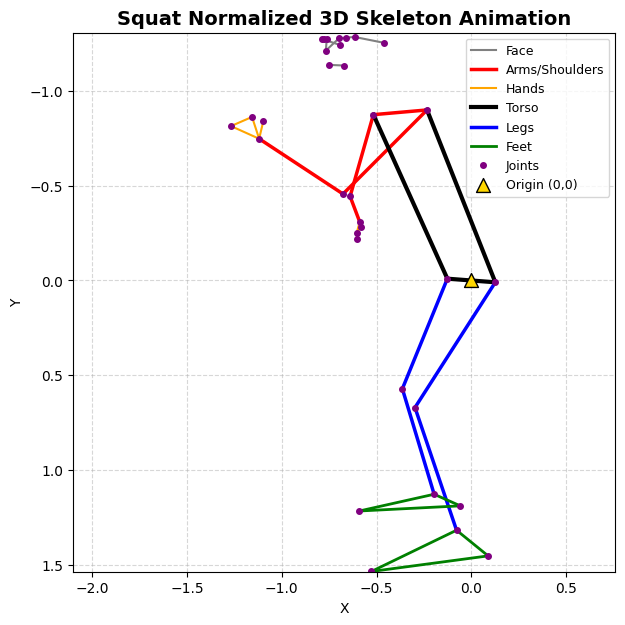

In [13]:
# notebook에서 matplotlib 애니메이션을 표시하기 위한 설정 (선택사항)
# %matplotlib notebook # 또는 %matplotlib inline (애니메이션 표시에 jshtml 방식 사용 시)

import matplotlib as mpl

# Notebook에서 jshtml 방식으로 애니메이션을 볼 때 필요한 설정 (가끔 주석 처리해야 작동하기도 함)
# mpl.rc('animation', html='jshtml')

# Cell 3에서 정규화 완료된 'normalized_landmarks_array' 사용

# 1. 시각화할 프레임 시퀀스 선택 (예: 스쿼트 동작이 포함된 연속된 90프레임)
# 실제 데이터의 시퀀스 ID 등을 기준으로 끊어서 사용해야 함
squat_idx = 0
animation_sequence = normalized_landmarks_array[squat_idx:squat_idx+200] # 90프레임 시퀀스 예시

# 2. 3D 스켈레톤 애니메이션 생성
print("Squat Animation Generating...")
squat_ani = animate_skeleton_2d(
    animation_sequence, 
    save_path="tests/squat_squat (2)_animation.gif", # GIF로 저장하려면 주석 해제 (저장 안 하려면 None)
    title=f"Squat Normalized 3D Skeleton Animation"
)

# Notebook에서 애니메이션 객체를 반환하여 표시
# 만약 `plot_skeleton_3d` 내부에서 `plt.show()`를 호출하지 않았고, 
# Notebook 설정을 마쳤다면 아래 줄만으로 애니메이션이 재생됨
squat_ani

In [ ]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 프로젝트 루트 경로를 sys.path에 추가 (ipynb 위치에 따라 조정)
# 현재 노트북이 notebooks/ 폴더 안에 있다면 '..'으로 루트를 지정합니다.
project_root = Path(".").resolve()  # 필요시 Path("../").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.pose_extraction import BlazePoseExtractor, ExtractionConfig, PoseNotDetectedError

# -------------------------------------------------------------
# 1. 설정 생성 (3D 좌표 x, y, z, visibility 모두 포함 시 include_z=True)
# -------------------------------------------------------------
config = ExtractionConfig(
    model_path="models/pose_landmarker_full.task",
    include_z=False,            # (x, y, visibility) -> shape (T, 33, 3)
    target_fps=None,            # None이면 원본 FPS 유지
    min_detected_ratio=0.1      # 전체 프레임 중 최소 10%는 검출되어야 함
)

input_video_path = "data/raw/Pushup2.mp4"  # 추출할 영상 경로
output_npy_path = "data/raw/sample_exercise_keypoints2.npy"

# -------------------------------------------------------------
# 2. 키포인트 추출 실행
# -------------------------------------------------------------
try:
    with BlazePoseExtractor(config) as extractor:
        print(f"[{input_video_path}] 키포인트 추출 시작...")
        keypoints, meta = extractor.extract_from_video(input_video_path)

    print("\n✅ 추출 완료!")
    print(f"- 키포인트 배열 Shape (T, J, C): {keypoints.shape}")
    print(f"- 메타데이터: {meta}")

    # -------------------------------------------------------------
    # 3. 데이터 (.npy) 저장
    # -------------------------------------------------------------
    save_path = Path(output_npy_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(save_path, keypoints)
    print(f"- .npy 저장 완료: {save_path.resolve()}")
except PoseNotDetectedError as e:
    print(f"❌ 포즈 검출 실패: {e}")
except FileNotFoundError as e:
    print(f"❌ 파일을 찾을 수 없습니다: {e}")

In [5]:
# 저장한 .npy 불러오기 검증
loaded_kps = np.load(output_npy_path)

print(f"로드된 데이터 Shape: {loaded_kps.shape}")

# 첫 번째 프레임(T=0)의 코(Nose, Index 0), 왼쪽 무릎(Left Knee, Index 25) 좌표 출력
# BlazePose 키포인트 Index: 0(Nose), 11/12(Shoulders), 23/24(Hips), 25/26(Knees), 27/28(Ankles)
first_frame = loaded_kps[0]
print("\n[프레임 0 주요 관절 좌표 (x, y, visibility)]")
print(f"- Nose (0): {first_frame[0]}")
print(f"- Left Knee (25): {first_frame[25]}")

# 시간(T) 흐름에 따른 오른쪽 무릎(Right Knee, Index 26) Y 좌표 변화 시각화 (스쿼트/운동 템포 확인)
plt.figure(figsize=(10, 4))
plt.plot(loaded_kps[:, 26, 1], label="Right Knee Y-coord (Normalized)", color="red")
plt.gca().invert_yaxis()  # 이미지 좌표계는 위쪽이 0이므로 Y축 반전
plt.title("Right Knee Y Coordinate Trajectory Across Frames")
plt.xlabel("Frame Index (T)")
plt.ylabel("Y Position")
plt.grid(True)
plt.legend()
plt.show()

NameError: name 'output_npy_path' is not defined

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

# 1. 프로젝트 루트 경로 지정 (노트북이 notebooks/ 내부에 있을 경우 Path("..") 로 설정)
project_root = Path(".").resolve()  # 필요 시 Path("../").resolve()

# 2. build_dataset 파이프라인 모듈 임포트
# (process_source_file은 DTW 위상정규화 도입으로 삭제됨 -> 새 영상 1개만 처리하고
#  싶으면 process_source_file_with_template(source, template, ...)을 대신 쓸 것.
#  여기서는 data/raw 전체를 한 번에 처리하는 build_dataset()만 있으면 된다.)
from src.preprocessing.build_dataset import build_dataset

print("✅ 모듈 로드 완료!")


✅ 모듈 로드 완료!


In [2]:
# 경로 및 매개변수 설정
RAW_DIR = project_root / "data" / "raw"
OUTPUT_DIR = project_root / "data" / "processed"
TARGET_LENGTH = 100  # 정규화할 타겟 프레임 수

# 데이터셋 전처리 파이프라인 실행
# min_distance/min_rep_frames는 지정하지 않으면 기본값(30)을 쓴다 — 실측 결과 15는
# 최저점에서 잠깐 멈칫하는 동작 습관이 있는 영상에서 하나의 rep을 여러 조각으로
# 잘못 쪼개는(과다 분절) 문제가 있어서 30으로 올린 값이다. 노이즈가 아주 심한
# 영상이면 min_distance=40~50까지 더 올리는 것도 고려할 것.
print("🚀 데이터셋 전처리 빌드 시작...")
build_dataset(
    raw_dir=RAW_DIR,
    output_dir=OUTPUT_DIR,
    manifest_path=None,  # 특정 manifest.csv 사용 시 Path("path/to/manifest.csv")
    target_length=TARGET_LENGTH,
)


🚀 데이터셋 전처리 빌드 시작...
처리 대상 파일 수: 81
[OK] pushup_pushup (1)_keypoints.npy: rep 2개 구간 추출 완료
[OK] pushup_pushup (10)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (11)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (12)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (13)_keypoints.npy: rep 35개 구간 추출 완료
[OK] pushup_pushup (14)_keypoints.npy: rep 2개 구간 추출 완료
[OK] pushup_pushup (15)_keypoints.npy: rep 7개 구간 추출 완료
[OK] pushup_pushup (16)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (17)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (18)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (19)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (2)_keypoints.npy: rep 56개 구간 추출 완료
[OK] pushup_pushup (20)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (21)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (22)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (23)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (24)_keypoints.npy: rep 1개 구간 추출 완료
[OK] pushup_pushup (25)_keypoi

In [3]:
# 1. 생성된 파일 확인
rep_seqs = np.load(OUTPUT_DIR / "rep_sequences.npy")
rep_features_df = pd.read_csv(OUTPUT_DIR / "rep_features.csv")

with open(OUTPUT_DIR / "build_log.json", "r", encoding="utf-8") as f:
    build_log = json.load(f)

print("===== 📊 전처리 결과 데이터 요약 =====")
print(f"• 생성된 Rep 시퀀스 Shape : {rep_seqs.shape}")
# shape 출력 예시: (전체 Rep 수, 100, 33, C)

print(
    f"• 성공 파일 수 : {len(build_log['success'])}개 / 실패 파일 수 : {len(build_log['failed'])}개"
)

# 2. 실패한 파일 로그 출력 (있을 경우)
if build_log["failed"]:
    print("\n⚠️ 실패 로그 예시:")
    for failed_info in build_log["failed"]:
        print(f" - 파일: {failed_info['file']} | 원인: {failed_info['reason']}")

# 3. Rep 특징 데이터프레임 미리보기 (메타데이터 + 각도 특징 컬럼)
meta_cols = ["video_id", "exercise", "rep_idx", "seq_index"]
feature_cols = [c for c in rep_features_df.columns if c not in meta_cols and not c.startswith("reliable_side_")]

print(f"\n• 특징 컬럼 ({len(feature_cols)}개): {feature_cols}")
print("\n===== 📝 rep_features.csv 상위 5개 행 =====")
display(rep_features_df.head())

# 4. seq_index와 rep_sequences.npy가 서로 어긋나지 않았는지 정합성 체크
assert len(rep_features_df) == rep_seqs.shape[0], "rep_features.csv 행 수와 rep_sequences.npy 시퀀스 수가 다릅니다!"
assert (rep_features_df["seq_index"].to_numpy() == np.arange(len(rep_features_df))).all(), \
    "seq_index가 0..N-1 순서와 어긋납니다!"
print("\n✅ rep_features.csv ↔ rep_sequences.npy 인덱스 정합성 확인 완료")

# 5. DTW 위상정규화에 쓰인 exercise별 템플릿(평균 궤적)도 함께 저장됐는지 확인
with np.load(OUTPUT_DIR / "templates.npz") as templates:
    print(f"\n===== 🧭 저장된 DTW 템플릿 =====")
    for exercise in templates.files:
        print(f" - {exercise}: 길이 {len(templates[exercise])}")


===== 📊 전처리 결과 데이터 요약 =====
• 생성된 Rep 시퀀스 Shape : (1140, 100, 33, 4)
• 성공 파일 수 : 81개 / 실패 파일 수 : 0개

• 특징 컬럼 (24개): ['min_angle_elbow', 'max_angle_elbow', 'rom_elbow', 'elbow_bin00', 'elbow_bin01', 'elbow_bin02', 'min_angle_hip', 'max_angle_hip', 'rom_hip', 'hip_bin00', 'hip_bin01', 'hip_bin02', 'min_angle_knee', 'max_angle_knee', 'rom_knee', 'knee_bin00', 'knee_bin01', 'knee_bin02', 'min_angle_shoulder', 'max_angle_shoulder', 'rom_shoulder', 'shoulder_bin00', 'shoulder_bin01', 'shoulder_bin02']

===== 📝 rep_features.csv 상위 5개 행 =====


,video_id,exercise,rep_idx,min_angle_elbow,max_angle_elbow,rom_elbow,elbow_bin00,elbow_bin01,elbow_bin02,reliable_side_elbow,...,knee_bin02,reliable_side_knee,min_angle_shoulder,max_angle_shoulder,rom_shoulder,shoulder_bin00,shoulder_bin01,shoulder_bin02,reliable_side_shoulder,seq_index
0,pushup (1),pushup,0,60.569016,172.771576,112.202560,150.408305,110.778291,143.615820,right,...,152.892694,right,0.065611,63.375797,63.310187,60.930733,33.906444,22.837896,right,0
1,pushup (1),pushup,1,54.810005,173.408157,118.598152,151.165061,112.475407,143.526815,right,...,152.556123,right,5.831530,66.383842,60.552312,61.273856,29.179289,22.032397,right,1
2,pushup (10),pushup,0,61.768913,179.336166,117.567253,150.571676,109.751433,143.156161,right,...,162.609382,right,0.209357,68.524506,68.315149,53.530239,27.350938,41.583820,right,2
3,pushup (11),pushup,0,81.661888,169.431351,87.769463,150.180539,114.961777,143.653044,right,...,163.687754,right,23.686113,79.360390,55.674276,68.410720,49.583545,66.393583,right,3
4,pushup (12),pushup,0,72.213554,176.441391,104.227837,150.517793,118.890942,143.928550,right,...,157.817573,right,2.408997,58.997707,56.588710,47.610538,29.840541,40.995209,right,4



✅ rep_features.csv ↔ rep_sequences.npy 인덱스 정합성 확인 완료

===== 🧭 저장된 DTW 템플릿 =====
 - pushup: 길이 100
 - squat: 길이 100
